##<b> The International Cricket Council (ICC) is the world governing body of cricket. It was founded as the Imperial Cricket Conference in 1909 by representatives from Australia, England and South Africa. It was renamed as the International Cricket Conference in 1965, and took up its current name in 1989. It organises world championship events such as Cricket World Cup, Women's Cricket World Cup, ICC T20 World Cup, ICC Women's T20 World Cup, ICC Champions Trophy and Under-19 Cricket World Cup.</b>

<br>

## <b> You recently got a lucky break in the field of Data Science. You got a job of Data Scientist at ICC. You are part of the Analytics Team which is involved in pre-match analyses, live-match analyses and post-match analyses. </b>

<br>

## <b>This data consists of 1417 T20 matches. Each row corresponds to a single T20 match. As a data scientist, you have to first explore the data and check its sanity. </b>

<br>

## <u><b>Further you are required to do some analyses :</b></u>
* ### Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date
* ### Find out the top three venues which hosted the greatest number of matches.
* ### Find out the pair of cricket teams who played the most number of T20 matches against each other.
* ### Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.
* ### Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.




# <b><center> A sample scorecard </center></b>

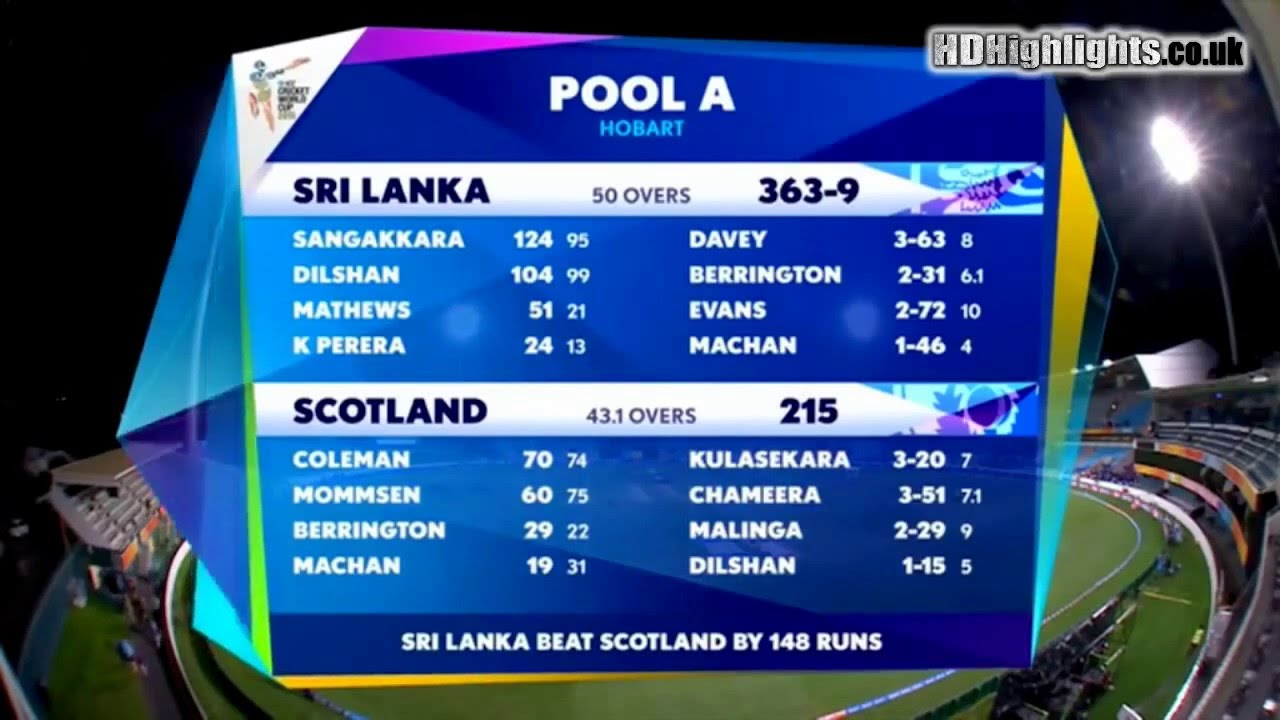

In [23]:
#Import package
import pandas as pd
import numpy as np
import ast

In [12]:
df = pd.read_csv(
    '/International_T20_Data.csv')

In [13]:
df.head()

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Sanity Checks**

In [14]:
df.describe()

,meta.data_version,meta.revision,info.outcome.by.wickets,info.overs,info.outcome.by.runs,info.match_type_number,info.neutral_venue
count,1.417000e+03,1417.000000,651.000000,1417.000000,721.000000,684.000000,328.0
mean,9.000000e-01,1.370501,6.476190,20.063514,39.088766,748.774854,1.0
std,5.108829e-15,0.575198,1.987802,1.379399,33.385757,190.050264,0.0
min,9.000000e-01,1.000000,1.000000,20.000000,1.000000,380.000000,1.0
25%,9.000000e-01,1.000000,5.000000,20.000000,13.000000,627.000000,1.0
50%,9.000000e-01,1.000000,7.000000,20.000000,30.000000,746.500000,1.0
75%,9.000000e-01,2.000000,8.000000,20.000000,56.000000,883.250000,1.0
max,9.000000e-01,5.000000,10.000000,50.000000,249.000000,1104.000000,1.0


In [15]:
# Dimension of datasets
print("No. of rows:", df.shape[0],"No. of columns", df.shape[1])
print(df.info)

No. of rows: 1417 No. of columns 27
<bound method DataFrame.info of                                                 innings  meta.data_version  \
0     [{'1st innings': {'team': 'Australia', 'delive...                0.9   
1     [{'1st innings': {'team': 'Australia', 'delive...                0.9   
2     [{'1st innings': {'team': 'Australia', 'delive...                0.9   
3     [{'1st innings': {'team': 'Hong Kong', 'delive...                0.9   
4     [{'1st innings': {'team': 'Zimbabwe', 'deliver...                0.9   
...                                                 ...                ...   
1412  [{'1st innings': {'team': 'Sri Lanka', 'delive...                0.9   
1413  [{'1st innings': {'team': 'Bangladesh', 'deliv...                0.9   
1414  [{'1st innings': {'team': 'Netherlands', 'deli...                0.9   
1415  [{'1st innings': {'team': 'Australia', 'delive...                0.9   
1416  [{'1st innings': {'team': 'Sri Lanka', 'delive...                0.9

In [16]:
#identifying missing values
missing_data = df.isnull().sum() #total no. of missing data
missing_data = missing_data[missing_data > 0].sort_values(ascending=False) #only columns which are have missing values

print("Columns with missing values:")
if missing_data.empty:
    print("No missing values found! The data is perfectly clean.")
else:
    print(missing_data)

Columns with missing values:
info.supersubs.South Africa    1416
info.supersubs.New Zealand     1416
info.outcome.bowl_out          1415
info.bowl_out                  1415
info.outcome.eliminator        1401
info.outcome.result            1372
info.outcome.method            1366
info.neutral_venue             1089
info.outcome.by.wickets         766
info.match_type_number          733
info.outcome.by.runs            696
info.city                       189
info.player_of_match            162
info.outcome.winner              45
info.umpires                     22
dtype: int64


In [17]:
#checking for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows found: {duplicate_count}")


Number of duplicate rows found: 0


In [18]:
# Exploring Categorial Data
if 'info.outcome.result' in df.columns:
    print("Types of Match Results:")
    print(df['info.outcome.result'].value_counts(dropna=False))

# Check unique values in 'gender' to ensure this is purely men's or women's T20, or a mix
if 'info.gender' in df.columns:
    print("\nGender Categories:")
    print(df['info.gender'].value_counts())


Types of Match Results:
info.outcome.result
NaN          1372
no result      26
tie            19
Name: count, dtype: int64

Gender Categories:
info.gender
male      951
female    466
Name: count, dtype: int64


# **Given Analysis**


*   Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date










In [19]:
# Replace '.' with '_'
df.columns = df.columns.str.replace('.', '_')

# Rename columns
df.rename(columns={
    'meta_data_version':'data_version',
    'meta_created':'created_date',
    'meta_revision':'revision',
    'info_dates':'match_date',
    'info_gender':'gender',
    'info_match_type':'match_type',
    'info_match_type_number':'match_number',
    'info_overs':'overs',
    'info_teams':'teams',
    'info_venue':'venue',
    'info_city':'city',
    'info_umpires':'umpires',
    'info_player_of_match':'player_of_match',
    'info_toss_winner':'toss_winner',
    'info_toss_decision':'toss_decision',
    'info_outcome_winner':'match_winner',
    'info_outcome_by_runs':'win_by_runs',
    'info_outcome_by_wickets':'win_by_wickets',
    'info_outcome_method':'result_method',
    'info_outcome_result':'match_result',
    'info_outcome_eliminator':'eliminator',
    'info_outcome_bowl_out':'bowl_out',
    'info_neutral_venue':'neutral_venue'
}, inplace=True)

# Save file
df.to_csv('International_T20_Data.csv', index=False)

print("Changes have been permanently saved to the CSV file.")

Changes have been permanently saved to the CSV file.




*   Find out the top three venues which hosted the greatest number of matches.




In [20]:
top_venues = df['venue'].value_counts().head(3)
print(top_venues)

venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64




*   Find out the pair of cricket teams who played the most number of T20 matches against each other.




In [21]:
df['teams'] = df['teams'].apply(lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x, str) else x)
df['team_pair'] = df['teams'].apply(lambda x: tuple(sorted(x)))
most_matches = df['team_pair'].value_counts().head(1)
print(most_matches)
df['teams'] = df['teams'].apply(lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x,str) else x)
matches_played = df['teams'].explode().value_counts()
matches_won = df['match_winner'].value_counts()
win_percentage = (matches_won / matches_played) * 100
top_teams = win_percentage.sort_values(ascending=False).head(5)
print(top_teams)


team_pair
(Australia, England)    45
Name: count, dtype: int64
Belgium        100.000000
Spain           83.333333
Germany         76.470588
Namibia         73.529412
Afghanistan     68.000000
Name: count, dtype: float64




*  Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.




In [28]:
# 1. Convert the 'teams' string into a real list for the whole column
#df['team_list'] = df['teams'].apply(ast.literal_eval)
def convert_team(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

df['team_list'] = df['teams'].apply(convert_team)

# 2. Explode the list so each team gets its own row, then count matches played
matches_played = df.explode('team_list')['team_list'].value_counts()

# 3. Count matches won by each team
matches_won = df['match_winner'].value_counts()

# 4. Calculate Win Percentage (Wins / Played * 100)
win_percentage = (matches_won / matches_played) * 100

# 5. Drop NaN values (teams with no wins or no result matches) and sort
top_5_teams = win_percentage.dropna().sort_values(ascending=False).head(5)

print("Top 5 Teams by Win Percentage:")
print(top_5_teams)


Top 5 Teams by Win Percentage:
Belgium        100.000000
Spain           83.333333
Germany         76.470588
Namibia         73.529412
Afghanistan     68.000000
Name: count, dtype: float64




*   Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.



In [29]:
df['innings'] = df['innings'].apply(ast.literal_eval)
def get_scorecard(innings):

    batsman_runs = {}
    bowler_wickets = {}

    for inning in innings:
        inning_data = list(inning.values())[0]

        for delivery in inning_data['deliveries']:

            ball = list(delivery.values())[0]

            batsman = ball['batsman']
            bowler = ball['bowler']
            runs = ball['runs']['batsman']

            batsman_runs[batsman] = batsman_runs.get(batsman, 0) + runs

            if 'wicket' in ball:
                bowler_wickets[bowler] = bowler_wickets.get(bowler, 0) + 1

    batsman_df = pd.DataFrame(
        batsman_runs.items(),
        columns=['Batsman','Runs']
    ).sort_values(by='Runs', ascending=False).head(4)

    bowler_df = pd.DataFrame(
        bowler_wickets.items(),
        columns=['Bowler','Wickets']
    ).sort_values(by='Wickets', ascending=False).head(4)

    return batsman_df, bowler_df

scorecard1, scorecard2 = get_scorecard(df['innings'][0])

print("Top 4 Batsmen")
print(scorecard1)

print("\nTop 4 Bowlers")
print(scorecard2)

Top 4 Batsmen
          Batsman  Runs
9   DAS Gunaratne    52
8  EMDY Munaweera    44
0        AJ Finch    43
1       M Klinger    38

Top 4 Bowlers
           Bowler  Wickets
3      SL Malinga        2
7       AJ Turner        2
6         A Zampa        2
0  PADLR Sandakan        1


# **Data Visulisation using matplotlib and seaborn**

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all plots to make them look professional
sns.set_theme(style="whitegrid")

1: Top 10 Venues (Horizontal Bar Chart)

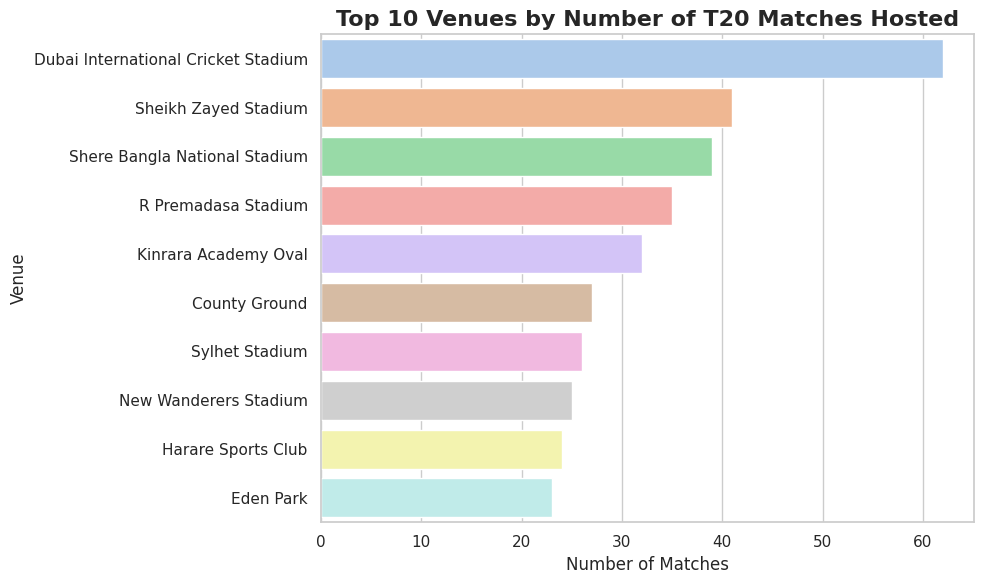

In [35]:
plt.figure(figsize=(10, 6))

# Grab the top 10 venues
top_10_venues = df['venue'].value_counts().head(10)

# FIXED LINE: Added hue=top_10_venues.index and legend=False
sns.barplot(x=top_10_venues.values, y=top_10_venues.index, hue=top_10_venues.index, palette='pastel', legend=False)

plt.title('Top 10 Venues by Number of T20 Matches Hosted', fontsize=16, fontweight='bold')
plt.xlabel('Number of Matches', fontsize=12)
plt.ylabel('Venue', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

2:Top 10 Teams by Win Percentage (Vertical Bar Chart)

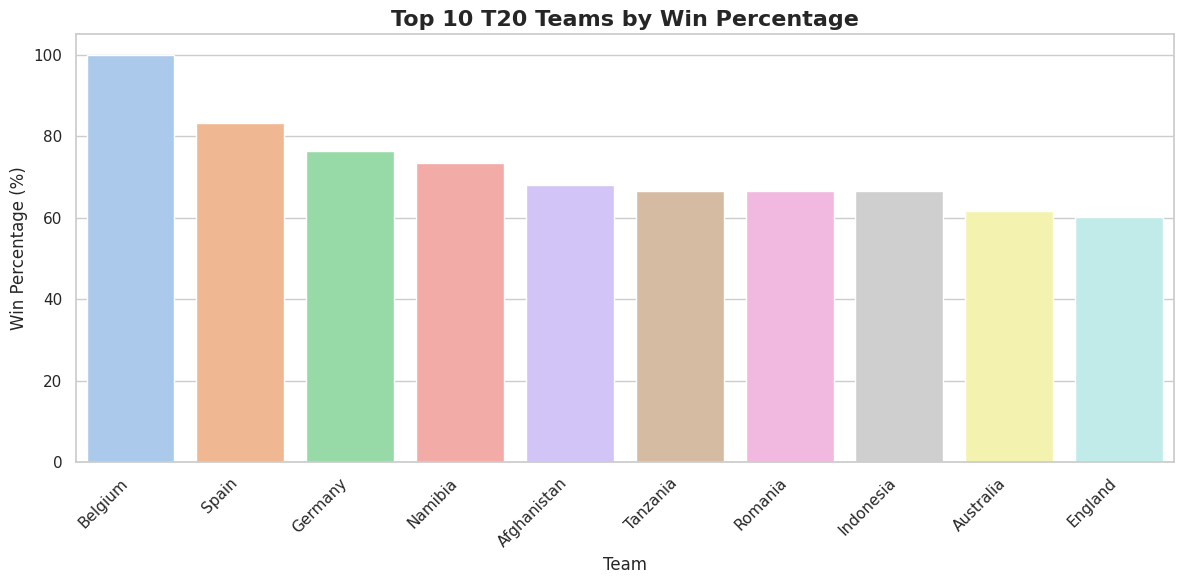

In [38]:
plt.figure(figsize=(12, 6))

# Calculate top 10 teams
top_10_teams = win_percentage.dropna().sort_values(ascending=False).head(10)

# FIXED LINE: Added hue=top_10_teams.index and legend=False
sns.barplot(x=top_10_teams.index, y=top_10_teams.values, hue=top_10_teams.index, palette='pastel', legend=False)

plt.title('Top 10 T20 Teams by Win Percentage', fontsize=16, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Win Percentage (%)', fontsize=12)

# Rotate the x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

3: Toss Decision (Pie Chart)

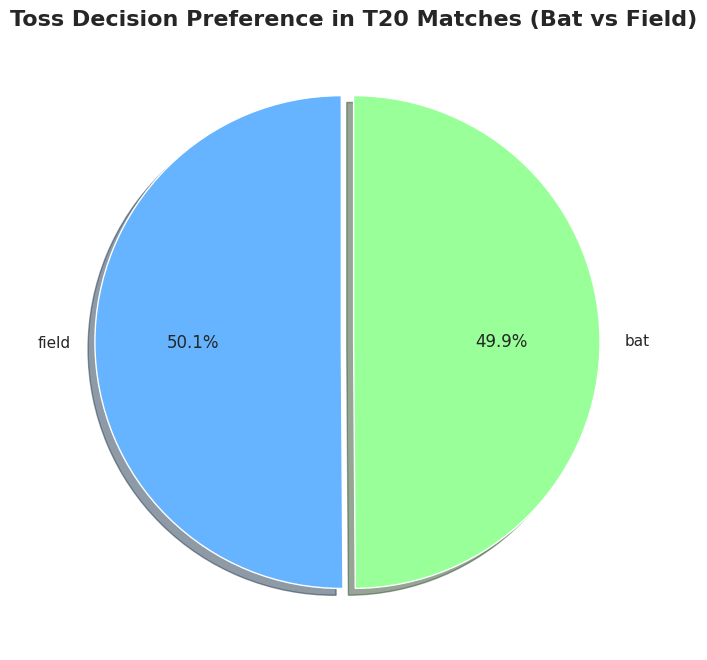

In [41]:
plt.figure(figsize=(8, 8))

# Count how many times captains chose to bat vs field
toss_counts = df['toss_decision'].value_counts()

# Create a pie chart using Matplotlib
plt.pie(toss_counts.values, labels=toss_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff','#99ff99'], explode=(0.05, 0), shadow=True)

plt.title('Toss Decision Preference in T20 Matches (Bat vs Field)', fontsize=16, fontweight='bold')

plt.show()

